**I am interested in exploring how youngs modulus affects the initial optimisation**

In [5]:
#Let's add libraries:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display
from sympy import symbols, Eq, solve

**Include initial variables**

In [30]:
#Change this for every new material!

style={'description_width':'initial'}
#Make sure that the titles dont get truncated and the titles are important because otherwise ill forget our units
#Ok, redo all I had before but now add it all as sliders/input fields?


rho_input=widgets.BoundedFloatText(value=0.9, min=0.0, max=100, step=0.1, description='Density (g/cm^3):', style=style)
display(rho_input)

cost_input=widgets.BoundedFloatText(value=1.6, min=0.0, max=100, step=0.1, description='Cost ($/kg):', style=style)
display(cost_input)

BoundedFloatText(value=0.9, description='Density (g/cm^3):', step=0.1, style=DescriptionStyle(description_widt…

BoundedFloatText(value=1.6, description='Cost ($/kg):', step=0.1, style=DescriptionStyle(description_width='in…

**Add hard limitations for model and define some constants**

In [52]:
pi=np.pi #I would go crazy writing np.pi so I'm just replacing it

p_atm=101325 #Atmospheric pressure in Pa

R=8.3144598 #Gas constant in J/mol/K

V_lim_outgassed=0.0048 #When the gas has escaped, the maximum volume cannot be below 4.8L because then there really is definitely not enough buoyancy

V_lim_initial=0.0052 #If volume is <5.2L initially, then it does not provide enough buoyancy. I mean, 5L is enough, but you want some redundancy.

V_max=0.006 #We do not want the initial volume to be >6L, because then that's too bulky for nifty rescues. ALso uses too many resources. Optimisation probably won't ever want to bring it above that but worth putting this out there, anyway.

rho=rho_input.value*1e3

cost=cost_input.value


I was initially doing the calculations with hand-inputted values and manual calculations. I then tested it with well-known numbers from a baloon, and it worked perfectly, returning values as expected. However, doing so has made me realise that I need an optimisation algorithm, in order to understand exactly how to choose r_0, T_0, etc such that it still produces the required 5-6L of volume at the start, but stays satiable. Otherwise I could hike thickness and then hike initial radius with it, without realising that I could be manually lowering both. In essence, there is too many variables for me to try and optmise everything by hand. For this, I will use the SciPy's optimise library. Here is some documentation on it, with some cool linear algebra examples:
https://docs.scipy.org/doc/scipy/tutorial/optimize.html. Here is a good, very simple CodeCademy resource that got me understanding how this works from a functional, not mathematical perspective: https://www.codecademy.com/resources/docs/scipy/scipy-optimize/minimize

Here's a good video example: https://www.youtube.com/watch?v=_aNYFXwzFno.

This is how I understand it works from reading a bit and watching some videos, but I could be very wrong. Each variable we're trying to optimise can be arranged in a vector, and given weights based on how important they are, as well as normalisation factors such that the weight of each component is only dependent on its importance. Various algorithms from the SciPy library can be used for optimisation purposes, but in our case with so many variables and wanting to use gradient search in our vector space, a SQSL algorithms should work well (and also, that's the only algorithm I've seen used in examples). We can also introduce constraints, including as functional constraints.

Optimisation completed for E=1.0 MPa
Optimal initial radius, r_0: 76.8 mm, or 0.08 m

Optimal thickness, T_0: 0.300 mm, or 0.000300 m

Optimal mass of reactants: 44.98 g, making 0.2149350311984946 moles of CO2.

The initial mass of the packed material is 0.0200 kg, or 20.0 g

The initial mass of everything together is 64.9769 g



Optimisation completed for E=3.020408163265306 MPa
Optimal initial radius, r_0: 76.8 mm, or 0.08 m

Optimal thickness, T_0: 0.300 mm, or 0.000300 m

Optimal mass of reactants: 45.99 g, making 0.21976366050105978 moles of CO2.

The initial mass of the packed material is 0.0200 kg, or 20.0 g

The initial mass of everything together is 65.9874 g



Optimisation completed for E=5.040816326530612 MPa
Optimal initial radius, r_0: 76.8 mm, or 0.08 m

Optimal thickness, T_0: 0.300 mm, or 0.000300 m

Optimal mass of reactants: 47.00 g, making 0.22459228980362475 moles of CO2.

The initial mass of the packed material is 0.0200 kg, or 20.0 g

The initial mass of everyth

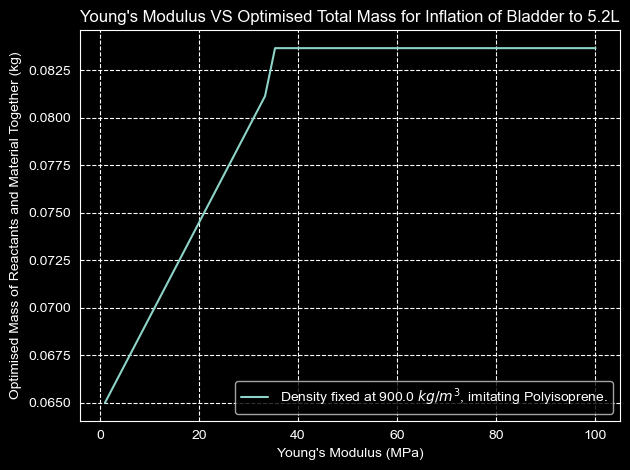

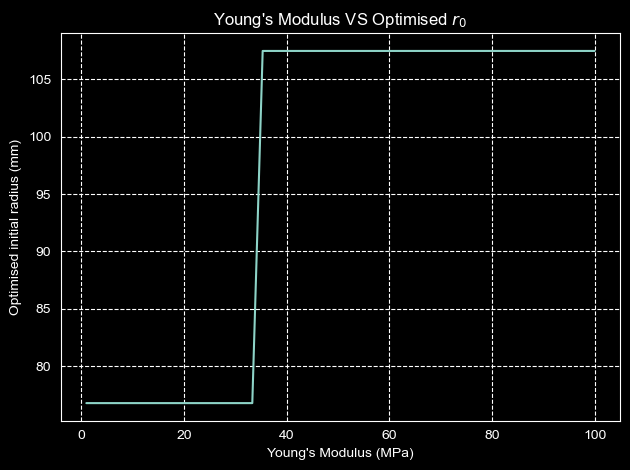

In [67]:
E_values=np.linspace(1,100,50) #Create an array for Youngs Moduli (MPa) instead

E_list=[]
r_0_list=[]
mass_list=[]
n_0_list=[]
for E_current in E_values:
    E=E_current*1e6

    def objective_function(x): #A function for what we're actually trying to minimise
        r_0, T_0, n_0, r=x #Include variables for optimisation

        materialVolume = 4*pi*(r_0**2)*T_0
        materialMass=materialVolume*rho
        MassReactants=0.34*n_0*0.192+n_0*0.084+(n_0/0.25)*0.015 #Mass of reactant A and B, including stoichiometry plus 15mL of water for every quarter mol for reactants to dissolve. This is a hypothetical but closely resembles other gas generation systems
        return materialMass+MassReactants #We want the mass of reactants to be minimised

    #Redefine pressure constrain function inside the loop because that's the only constraint that is ependent on youngs modulus
    def pressure_constraint(x):
        r_0, T_0, n_0, r=x
        p_res=(2*E*r_0*T_0*(r-r_0))/(r**3)
        p_gas=(3*n_0*R*Temp)/(4*pi*r**3)

        return p_gas-p_res-p_atm

    def min_volume(x):
        r=x[3] #Take r from array as defined previously
        V=4/3*pi*(r**3)
        return V-V_lim_initial

    def max_volume(x):
        r=x[3]
        V=4/3*pi*(r**3)
        return V_max-V #We will say that V_max-V>=0 of course

    def stretch_lim(x): #We do not want the material to stretch any more than ~100% of its original volume. At that point, any material would be too stretched out and prone to popping, which wouldn't be ok in aquatic environments. So radius can't be greater than 1.26 r_0 (given the proportionalities). NB 27/4/26 - this was changed to be softer - we're allowing for a 1.4r_0 stretch to alleviate constraints.
        r_0=x[0]
        r=x[3]
        return 1.4*r_0-r #We want the radius to be less than 1.4 r_0, so that the material is not too stretched out.

    def stretch_min(x): #Very interestingly, playing around with Young's Moduli made me realise that there's no constraint to force pressures to be positive. Now, of course, we're not creating a vaccuum - we're creating gas. So we need to define a minimum stretch (the material must at least stretch outwards... Not inwards).
        r_0=x[0]
        r=x[3]
        return r-r_0

    #Redefine constraints since one changed
    cons=[{'type':'eq', 'fun':pressure_constraint}, {'type':'ineq', 'fun':min_volume}, {'type':'ineq', 'fun':max_volume}, {'type':'ineq', 'fun':stretch_lim}, {'type':'ineq', 'fun':stretch_min}] #Add constraints as equalities and inequalities

    x0 = [0.09, 0.00005, 0.23, 0.1]

    bounds = (
    (0.005,0.5), #Very rough bounds for r_0
    (0.0003,0.003), #Keep T_0 it thin - from 0.3 mm to 3 mm (upper bound doesn't matter, it will never optimise for it anyway)
    (0.05,0.5), #Please no more than 0.5 moles CO2, this would require so many reactants.
    (0.01,1.4) #Give the optimisation algorithm very rough bounds of radius, r. Must be at least 0.1 though for at least 5L volume at start
)

    solution_E=minimize(objective_function, x0, method='SLSQP', bounds=bounds, constraints=cons)
    if solution_E.success:
        opt_r_0, opt_T_0, opt_n_0, opt_r = solution_E.x
        opt_V = (4/3) * pi * opt_r**3
        materialVolume = 4*pi*(opt_r_0**2)*opt_T_0
        materialMass=materialVolume*rho
        massReactants=0.34*opt_n_0*0.192+opt_n_0*0.084+(opt_n_0/0.25)*0.015
        E_list.append(E_current)
        r_0_list.append(opt_r_0*1000)
        mass_list.append(materialMass+massReactants)
        n_0_list.append(opt_n_0)

        print(f"Optimisation completed for E={E_current} MPa")
        print(f"Optimal initial radius, r_0: {opt_r_0*1000:.1f} mm, or {opt_r_0:.2f} m\n")
        print(f"Optimal thickness, T_0: {opt_T_0*1000:.3f} mm, or {opt_T_0:.6f} m\n")
        print(f"Optimal mass of reactants: {massReactants*1e3:.2f} g, making {opt_n_0} moles of CO2.\n")
        #print(f"Initial, blown up volume, is then: {opt_V*1000:.2f} L or {opt_V:.2f} m^3")
        #Calculate packed material mass from the area of the material initially, taken as a sphere with r_0 radius, using thickness and density to find mass of material. This was repurposed from an old cell above.
        SA=4*pi*opt_r_0**2 #Surface area of our material
        V_material=SA*opt_T_0 #Volume of our material
        MaterialMass=V_material*rho
        MaterialCost=MaterialMass*cost
        print(f"The initial mass of the packed material is {MaterialMass:.4f} kg, or {MaterialMass*1e3:.1f} g\n")
        print(f"The initial mass of everything together is {(MaterialMass+massReactants)*1e3:.4f} g")
        #print(f"The cost of the packed material is ${MaterialCost:.4f}")
        print("\n\n")

    else:
        print(f'E={E_current} failed to optimise {solution_E.message}')


plt.plot(E_list, mass_list, label=f"Density fixed at {rho:.1f} $kg/m^3$, imitating Polyisoprene.")
plt.title("Young's Modulus VS Optimised Total Mass for Inflation of Bladder to 5.2L")
plt.xlabel("Young's Modulus (MPa)")
plt.ylabel("Optimised Mass of Reactants and Material Together (kg)")
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

plt.plot(E_list, r_0_list)
plt.title("Young's Modulus VS Optimised $r_0$")
plt.xlabel("Young's Modulus (MPa)")
plt.ylabel("Optimised initial radius (mm)")
#plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()